# Creep, Shrinkage, and Thermal Analysis

Creep, shrinkage and differential **temperature** all impose a *free*, stress-free strain field on a member. PyCBA models the curvature part of that field as an **imposed-curvature** load (load type&nbsp;6, added with `BeamAnalysis.add_ic`): on a statically determinate span it deflects the beam but produces no reactions, while on a **continuous** member the redundant supports restrain the free curvature and real continuity ("secondary") moments develop.

This tutorial applies a uniform imposed curvature to a continuous beam (Example&nbsp;1) and to a non-prismatic member (Example&nbsp;2), then works through an **AS&nbsp;5100.2 differential-temperature** analysis of a continuous bridge (Example&nbsp;3).

The companion tutorial, [Non-prismatic Elements](nonprismatic.ipynb), covers the variable-$EI$ element; the underlying method is in the [Theoretical Basis](../theory.md).

In [1]:
import pycba as cba
import numpy as np
import matplotlib.pyplot as plt
from pycba import SectionEI

## Example 1 - Imposed curvature on a continuous beam

An imposed curvature is *self-strained*: on a simply-supported span it produces
deflection but no reactions. On a **continuous** beam the restraint of the free
curvature generates real moments. For two equal spans under a uniform curvature
$\kappa$ the interior-support moment is $-1.5\,EI\kappa$ and the system is
self-equilibrating (zero net reaction).

In [2]:
# A uniform free curvature kappa on each span (e.g. shrinkage / thermal).
L, EI, kappa = 10.0, 180000.0, 1e-4
ba = cba.BeamAnalysis([L, L], EI, [-1, 0, -1, 0, -1, 0])
ba.add_ic(1, kappa)
ba.add_ic(2, kappa)
ba.analyze(npts=301)

res = ba.beam_results.results
M_pier = res.M[np.argmin(np.abs(res.x - L))]
print(f"Interior-support moment = {M_pier:7.2f} kNm  (closed form -1.5 EI k = {-1.5*EI*kappa:.2f})")
print(f"Sum of reactions        = {np.sum(ba.beam_results.R):+.2e} kN  (self-equilibrating)")

Interior-support moment =  -27.00 kNm  (closed form -1.5 EI k = -27.00)
Sum of reactions        = +0.00e+00 kN  (self-equilibrating)


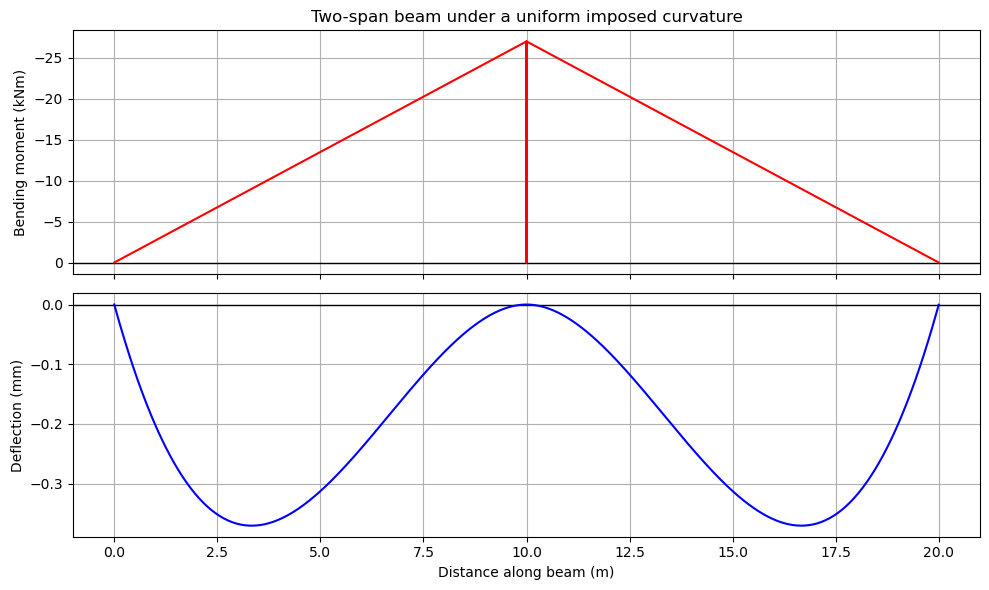

In [3]:
# Bending moment and deflected shape under the imposed curvature.
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].axhline(0, color="k", lw=1.0)
axs[0].plot(res.x, res.M, "r")
axs[0].invert_yaxis()
axs[0].set_ylabel("Bending moment (kNm)")
axs[0].set_title("Two-span beam under a uniform imposed curvature")
axs[0].grid(True)

axs[1].axhline(0, color="k", lw=1.0)
axs[1].plot(res.x, res.D * 1e3, "b")
axs[1].set_ylabel("Deflection (mm)")
axs[1].set_xlabel("Distance along beam (m)")
axs[1].grid(True)
fig.tight_layout()

## Example 2 - Imposed curvature on a non-prismatic member

The two features combine naturally: an imposed curvature applied to a
`SectionEI` member. The fixed-end forces are integrated across the section
breakpoints, so the variable rigidity is honoured exactly. Here the haunched
two-span beam from the [Non-prismatic Elements](nonprismatic.ipynb) tutorial
carries a uniform curvature &mdash; the stiffer pier attracts a larger restraint
moment than the prismatic beam.

In [4]:
# Build the same haunched two-span beam as in the Non-prismatic Elements
# tutorial, then apply the imposed curvature instead of a UDL.
E, b = 30.0e6, 1.0
Lsp, DC, Dh, Lh = 10.0, 0.6, 1.2, 3.0
EI_const = E * b * DC**3 / 12.0


def haunch_poly(d_end, d_pier, x_end, x_pier):
    """Parabolic depth: flat (vertex) at the shallow end (d_end at x_end),
    deepening to d_pier at the support (x_pier).  Returns an EI(x) callable."""
    def f(x):
        s = (np.asarray(x, float) - x_end) / (x_pier - x_end)
        return E * b * (d_end + (d_pier - d_end) * s**2) ** 3 / 12.0
    return f


sec1 = SectionEI([
    ("const", [0.0, Lsp - Lh], EI_const),
    ("poly",  [Lsp - Lh, Lsp], haunch_poly(DC, Dh, Lsp - Lh, Lsp), 6),
])
sec2 = SectionEI([   # mirror of span 1 about the pier
    ("poly",  [0.0, Lh], haunch_poly(DC, Dh, Lh, 0.0), 6),
    ("const", [Lh, Lsp], EI_const),
])

ba_np = cba.BeamAnalysis([Lsp, Lsp], [sec1, sec2], [-1, 0, -1, 0, -1, 0])
ba_np.add_ic(1, kappa)
ba_np.add_ic(2, kappa)
ba_np.analyze(npts=300)
M_pier_np = ba_np.beam_results.results.M.min()

# prismatic reference at the mid-depth rigidity
ba_npp = cba.BeamAnalysis([Lsp, Lsp], [EI_const, EI_const], [-1, 0, -1, 0, -1, 0])
ba_npp.add_ic(1, kappa)
ba_npp.add_ic(2, kappa)
ba_npp.analyze(npts=300)
M_pier_npp = ba_npp.beam_results.results.M.min()

print(f"Prismatic pier moment = {M_pier_npp:7.2f} kNm  (closed form -1.5 EI k = {-1.5*EI_const*kappa:.2f})")
print(f"Haunched  pier moment = {M_pier_np:7.2f} kNm  (stiffer pier draws more restraint moment)")
print(f"Sum of reactions      = {np.sum(ba_np.beam_results.R):+.2e} kN  (still self-equilibrating)")

Prismatic pier moment =  -81.00 kNm  (closed form -1.5 EI k = -81.00)
Haunched  pier moment = -122.36 kNm  (stiffer pier draws more restraint moment)
Sum of reactions      = +0.00e+00 kN  (still self-equilibrating)


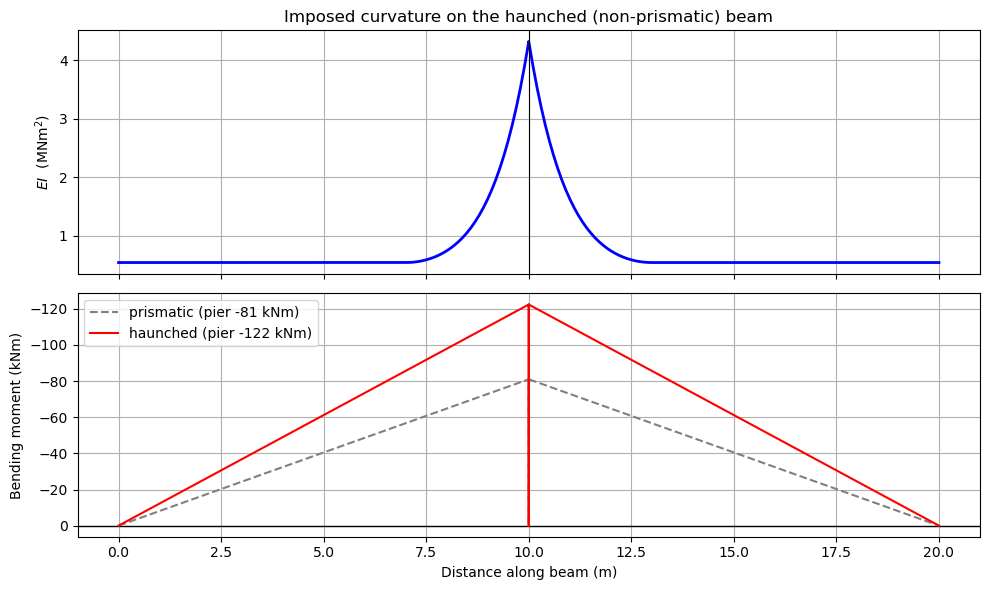

In [5]:
# EI(x) elevation and the resulting BMD (haunched vs prismatic).
xx = np.linspace(0.0, Lsp, 200)
EI_prof = np.concatenate([sec1(xx), sec2(xx)]) / 1e6
x_prof = np.concatenate([xx, Lsp + xx])

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].plot(x_prof, EI_prof, "b", lw=2)
axs[0].axvline(Lsp, color="k", lw=0.8)
axs[0].set_ylabel("$EI$  (MNm$^2$)")
axs[0].set_title("Imposed curvature on the haunched (non-prismatic) beam")
axs[0].grid(True)

axs[1].axhline(0, color="k", lw=1.0)
axs[1].plot(ba_npp.beam_results.results.x, ba_npp.beam_results.results.M, "0.5", ls="--",
            label=f"prismatic (pier {M_pier_npp:.0f} kNm)")
axs[1].plot(ba_np.beam_results.results.x, ba_np.beam_results.results.M, "r",
            label=f"haunched (pier {M_pier_np:.0f} kNm)")
axs[1].invert_yaxis()
axs[1].set_ylabel("Bending moment (kNm)")
axs[1].set_xlabel("Distance along beam (m)")
axs[1].grid(True)
axs[1].legend(loc="upper left")
fig.tight_layout()

## Example 3 - AS 5100.2 differential temperature on a continuous bridge

A vertical temperature gradient through a bridge superstructure imposes a free curvature; on a continuous bridge this is restrained and produces continuity moments. [AS&nbsp;5100.2 (Clause&nbsp;18.3)](../references.md) specifies the design *positive* (heating) gradient as the [**Priestley fifth-order curve**](../references.md) over the top 1200&nbsp;mm of the section,

$$\Delta T(y) = \Delta T_\mathrm{top}\left(1 - \frac{y}{1200}\right)^5 \qquad (0 \le y \le 1200~\mathrm{mm}),$$

with $y$ the depth below the top surface ($\Delta T_\mathrm{top}$ is taken from AS&nbsp;5100.2 for the surfacing and region; here we use the $\approx 32^\circ$C Priestley design value). The free curvature it imposes about the section centroid is

$$\kappa_T = \frac{\alpha}{I}\int \Delta T(y)\,(y_c - y)\,b\,\mathrm{d}y,$$

with $\alpha$ the coefficient of thermal expansion, $I$ the second moment of area and $y_c$ the centroid depth. We evaluate $\kappa_T$ for a solid deck, apply it with `add_ic`, and recover the continuity moments.

Free thermal curvature  kappa_T = 1.580e-04  1/m


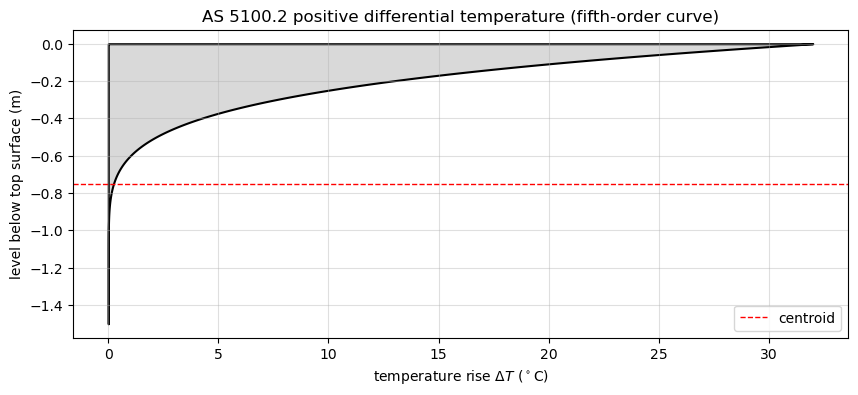

In [6]:
# AS 5100.2 Cl 18.3 positive (heating) gradient: Priestley fifth-order curve.
alpha = 12e-6                 # concrete thermal expansion, 1/degC (AS 5100.2)
d, b = 1.5, 1.0               # deck depth and a unit-width strip (m)
dT_top, y_grad = 32.0, 1.2    # peak surface rise (degC) and gradient depth (m)

def dT(y):                    # positive gradient; y = depth below the top surface (m)
    y = np.asarray(y, float)
    return np.where(y <= y_grad, dT_top * (1.0 - y / y_grad) ** 5, 0.0)

yc = d / 2.0                              # centroid depth (solid rectangular deck)
Igross = b * d ** 3 / 12.0
y = np.linspace(0.0, d, 2001)
kappa_T = alpha / Igross * np.trapezoid(dT(y) * (yc - y) * b, y)
print(f"Free thermal curvature  kappa_T = {kappa_T:.3e}  1/m")

# the imposed temperature profile through the depth
fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_betweenx(-y, 0.0, dT(y), facecolor="0.85", edgecolor="k", lw=1.5)
ax.axhline(-yc, color="r", ls="--", lw=1.0, label="centroid")
ax.set_xlabel("temperature rise $\\Delta T$ ($^\\circ$C)")
ax.set_ylabel("level below top surface (m)")
ax.set_title("AS 5100.2 positive differential temperature (fifth-order curve)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.4);

Peak continuity moment = 1571 kNm
Sum of reactions       = +7.1e-15 kN  (self-equilibrating)


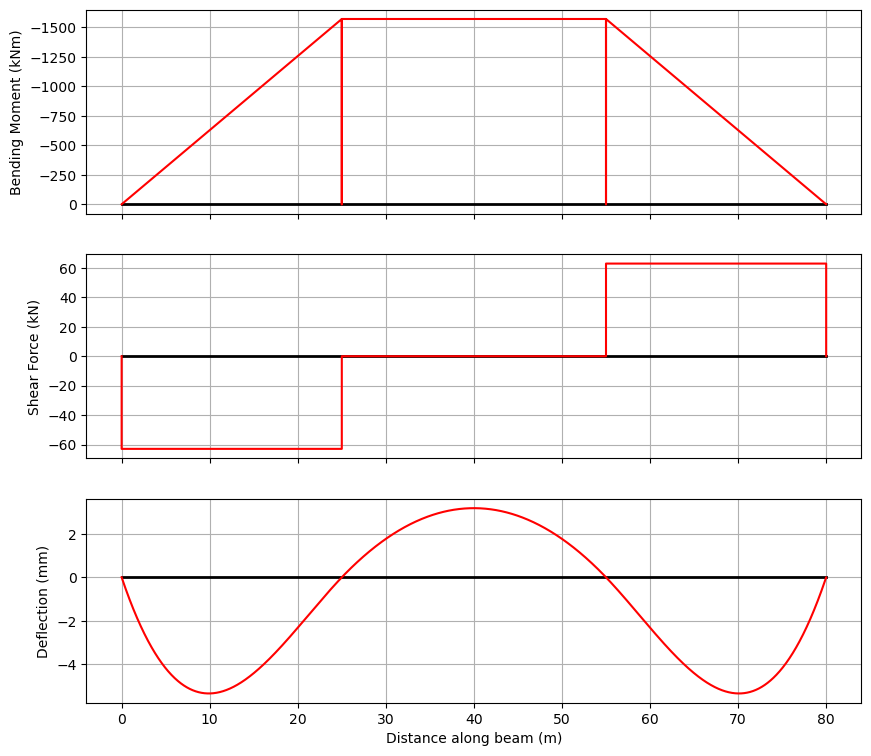

In [7]:
# apply the thermal curvature to a three-span continuous bridge
E = 30.0e6                                  # concrete modulus (kPa)
spans = [25.0, 30.0, 25.0]
EI = E * Igross
ba = cba.BeamAnalysis(spans, EI, [-1, 0, -1, 0, -1, 0, -1, 0])
for s in range(1, len(spans) + 1):
    ba.add_ic(s, kappa_T)                   # the free thermal curvature on every span
ba.analyze(npts=601)

res = ba.beam_results.results
print(f"Peak continuity moment = {np.max(np.abs(res.M)):.0f} kNm")
print(f"Sum of reactions       = {np.sum(ba.beam_results.R):+.1e} kN  (self-equilibrating)")
ba.plot_results(show_beam=False);